# Prediction Nutri-Score — Version XGBoost + SHAP

Ameliorations par rapport aux notebooks precedents :

| # | Levier | Detail |
|---|---|---|
| 1 | **Features etendues** | `nova_group`, `additives_n`, ratios derives |
| 2 | **IterativeImputer (ExtraTrees)** | Imputation iterative robuste |
| 3 | **XGBoost** | Classifieur gradient boosting performant et interpretable |
| 4 | **Class weight** | Equilibrage automatique des grades |
| 5 | **RandomizedSearchCV** | Optimisation des hyperparametres |
| 6 | **Scoring complet** | Rapport, F1 par grade, matrices de confusion |
| 7 | **SHAP** | Interpretabilite et suivi du modele (valeurs de Shapley) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    XGB_OK = False
    print("XGBoost non installe, on utilise GradientBoostingClassifier a la place.")
    print("Pour installer : pip install xgboost")

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print("SHAP non installe. Pour installer : pip install shap")

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
print(f"XGBoost disponible : {XGB_OK}")
print(f"SHAP disponible    : {SHAP_OK}")

XGBoost disponible : True
SHAP disponible    : True


## 1. Chargement des datasets

In [2]:
TARGET = 'nutriscore_grade'
GRADES_VALIDES = ['a', 'b', 'c', 'd', 'e']

def charger(path):
    import os
    for p in [path, '../' + path, 'Nutri/' + path]:
        if os.path.exists(p):
            return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Introuvable : {path}")

df_train = charger('traité_avec_nutriscore.csv')
df_train[TARGET] = df_train[TARGET].str.lower().str.strip()
df_train = df_train[df_train[TARGET].isin(GRADES_VALIDES)]

df_pred = charger('traité_sans_nutriscore.csv')

print(f"Entrainement  : {len(df_train):,} produits")
print(f"A predire     : {len(df_pred):,} produits")
print(f"\nDistribution des grades :")
print(df_train[TARGET].value_counts().sort_index())

Entrainement  : 58,903 produits
A predire     : 32,394 produits

Distribution des grades :
nutriscore_grade
a    11846
b    11722
c    11803
d    11800
e    11732
Name: count, dtype: int64


## 2. Feature Engineering

On etend les features de base (7 nutriments) avec :
- `nova_group` et `additives_n` : tres correles au Nutri-Score  
- Ratios derives : `sugars_ratio`, `sat_fat_ratio`

In [3]:
BASE_FEATURES = [
    'energy_100g',
    'sugars_100g',
    'saturated-fat_100g',
    'salt_100g',
    'fiber_100g',
    'proteins_100g',
    'fruits-vegetables-legumes_100g',
]

def feature_engineering(df):
    df = df.copy()
    # Converti les colonnes numeriques
    for col in BASE_FEATURES + ['nova_group', 'additives_n', 'carbohydrates_100g', 'fat_100g']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Ratios derives (eviter division par zero)
    if 'sugars_100g' in df.columns and 'carbohydrates_100g' in df.columns:
        df['sugars_ratio'] = df['sugars_100g'] / (df['carbohydrates_100g'] + 1e-6)
    if 'saturated-fat_100g' in df.columns and 'fat_100g' in df.columns:
        df['sat_fat_ratio'] = df['saturated-fat_100g'] / (df['fat_100g'] + 1e-6)

    return df

df_train = feature_engineering(df_train)
df_pred  = feature_engineering(df_pred)

# Features finales
EXTRA_FEATURES = ['nova_group', 'additives_n', 'sugars_ratio', 'sat_fat_ratio']
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES

features_dispo = [f for f in ALL_FEATURES if f in df_train.columns]
print(f"Features utilisees ({len(features_dispo)}) :")
for f in features_dispo:
    n_null = df_train[f].isna().sum()
    pct = 100 * n_null / len(df_train)
    print(f"  {f:<40} {n_null:>7,} NaN ({pct:5.1f}%)")

Features utilisees (10) :
  sugars_100g                                    0 NaN (  0.0%)
  saturated-fat_100g                             0 NaN (  0.0%)
  salt_100g                                      0 NaN (  0.0%)
  fiber_100g                                     0 NaN (  0.0%)
  proteins_100g                                  0 NaN (  0.0%)
  fruits-vegetables-legumes_100g                 0 NaN (  0.0%)
  nova_group                                 2,637 NaN (  4.5%)
  additives_n                                    0 NaN (  0.0%)
  sugars_ratio                                   0 NaN (  0.0%)
  sat_fat_ratio                                  0 NaN (  0.0%)


In [4]:
X = df_train[features_dispo]
y = df_train[TARGET]

# Encodage numerique des labels pour XGBoost
le = LabelEncoder()
y_enc = le.fit_transform(y)  # a->0, b->1, c->2, d->3, e->4
print(f"Classes encodees : {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train : {len(X_train):,}  |  Test (hold-out 20%) : {len(X_test):,}")

Classes encodees : {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4}
Train : 47,122  |  Test (hold-out 20%) : 11,781


## 3. Pipeline : IterativeImputer + XGBoost

- **Imputation** : `IterativeImputer` avec `ExtraTreesRegressor`  
- **Classifieur** : `XGBClassifier` (ou `GradientBoostingClassifier` si XGBoost absent)  
- **scale_pos_weight** / `sample_weight` : compense le desequilibre entre grades

In [5]:
imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42,
    verbose=0
)

if XGB_OK:
    clf = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=5,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
else:
    clf = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

pipeline = Pipeline([
    ('imputer', imputer),
    ('clf', clf)
])

clf_name = 'XGBClassifier' if XGB_OK else 'GradientBoostingClassifier'
print(f"Pipeline pret : IterativeImputer -> {clf_name}")

Pipeline pret : IterativeImputer -> XGBClassifier


## 4. Cross-Validation Stratifiee (k=5)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

df_cv = pd.DataFrame({
    'Fold'           : range(1, 6),
    'Train Accuracy' : cv_results['train_accuracy'].round(4),
    'Val Accuracy'   : cv_results['test_accuracy'].round(4),
    'Val F1-macro'   : cv_results['test_f1_macro'].round(4),
})
print(df_cv.to_string(index=False))
print(f"\nMoyenne Val Accuracy : {df_cv['Val Accuracy'].mean():.4f} +/- {df_cv['Val Accuracy'].std():.4f}")
print(f"Moyenne Val F1-macro : {df_cv['Val F1-macro'].mean():.4f} +/- {df_cv['Val F1-macro'].std():.4f}")

 Fold  Train Accuracy  Val Accuracy  Val F1-macro
    1          0.9543        0.9004        0.9006
    2          0.9572        0.8897        0.8900
    3          0.9570        0.8966        0.8971
    4          0.9540        0.9003        0.9007
    5          0.9561        0.8916        0.8920

Moyenne Val Accuracy : 0.8957 +/- 0.0049
Moyenne Val F1-macro : 0.8961 +/- 0.0049


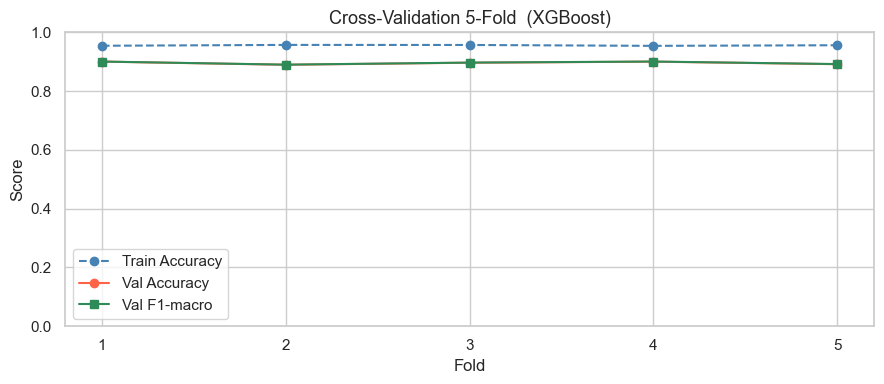

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, 6)
ax.plot(x, cv_results['train_accuracy'], 'o--', label='Train Accuracy', color='steelblue')
ax.plot(x, cv_results['test_accuracy'],  'o-',  label='Val Accuracy',   color='tomato')
ax.plot(x, cv_results['test_f1_macro'],  's-',  label='Val F1-macro',   color='seagreen')
ax.set_xticks(list(x))
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Cross-Validation 5-Fold  (XGBoost)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Optimisation des hyperparametres (RandomizedSearchCV)

On cherche les meilleurs parametres du classifieur via 15 iterations aleatoires.  
**Note** : cette cellule peut prendre plusieurs minutes.

In [8]:
if XGB_OK:
    param_dist = {
        'clf__n_estimators'    : [200, 300, 500],
        'clf__learning_rate'   : [0.03, 0.05, 0.1, 0.15],
        'clf__max_depth'       : [5, 7, 10],
        'clf__subsample'       : [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
        'clf__min_child_weight': [1, 3, 5],
        'clf__gamma'           : [0, 0.1, 0.3],
    }
else:
    param_dist = {
        'clf__n_estimators'  : [200, 300, 500],
        'clf__learning_rate' : [0.03, 0.05, 0.1],
        'clf__max_depth'     : [3, 5, 7],
        'clf__min_samples_leaf': [5, 10, 20],
    }

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print(f"\nMeilleur F1-macro CV : {search.best_score_:.4f}")
print("Meilleurs parametres :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

best_pipeline = search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Meilleur F1-macro CV : 0.9012
Meilleurs parametres :
  clf__subsample: 0.7
  clf__n_estimators: 200
  clf__min_child_weight: 3
  clf__max_depth: 10
  clf__learning_rate: 0.1
  clf__gamma: 0
  clf__colsample_bytree: 1.0


## 6. Evaluation finale sur le Hold-out (20%)

In [9]:
y_pred_enc = best_pipeline.predict(X_test)
y_pred     = le.inverse_transform(y_pred_enc)
y_test_lbl = le.inverse_transform(y_test)

acc = accuracy_score(y_test_lbl, y_pred)
f1  = f1_score(y_test_lbl, y_pred, average='macro')

print(f"Hold-out Accuracy  : {acc:.4f}")
print(f"Hold-out F1-macro  : {f1:.4f}")
print()
print(classification_report(y_test_lbl, y_pred, digits=4))

Hold-out Accuracy  : 0.9114
Hold-out F1-macro  : 0.9115

              precision    recall  f1-score   support

           a     0.9299    0.9190    0.9244      2369
           b     0.8564    0.8985    0.8770      2344
           c     0.8999    0.8717    0.8855      2361
           d     0.9140    0.9229    0.9184      2360
           e     0.9598    0.9450    0.9523      2347

    accuracy                         0.9114     11781
   macro avg     0.9120    0.9114    0.9115     11781
weighted avg     0.9120    0.9114    0.9115     11781



In [10]:
report = classification_report(y_test_lbl, y_pred, digits=4, output_dict=True)
df_report = pd.DataFrame(report).T
df_report['support'] = df_report['support'].astype(int)

display(df_report.style
    .format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1-score': '{:.4f}', 'support': '{:,d}'})
    .background_gradient(subset=['precision', 'recall', 'f1-score'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption(f"Hold-out Accuracy : {acc:.4f}  |  F1-macro : {f1:.4f}")
)

,precision,recall,f1-score,support
a,0.9299,0.9190,0.9244,"2,369"
b,0.8564,0.8985,0.8770,"2,344"
c,0.8999,0.8717,0.8855,"2,361"
d,0.9140,0.9229,0.9184,"2,360"
e,0.9598,0.9450,0.9523,"2,347"
accuracy,0.9114,0.9114,0.9114,0
macro avg,0.9120,0.9114,0.9115,"11,781"
weighted avg,0.9120,0.9114,0.9115,"11,781"


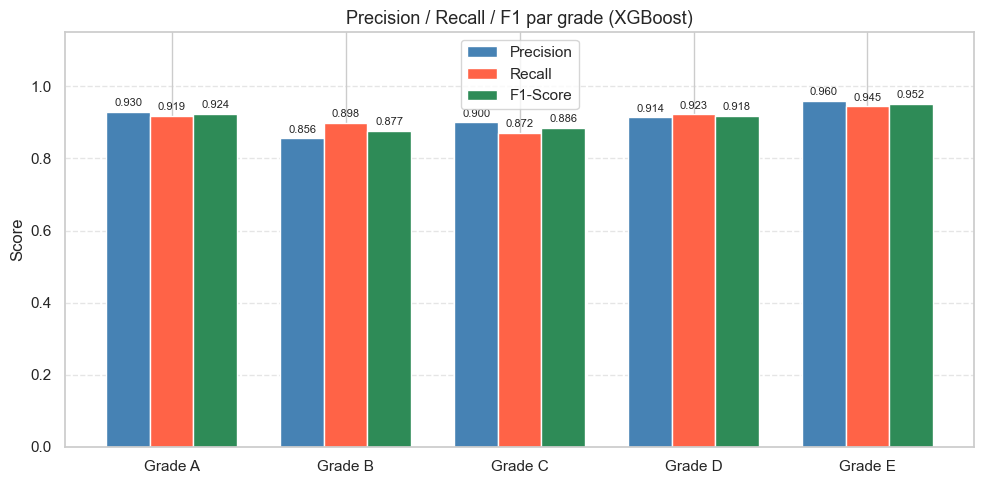

In [11]:
grades = ['a', 'b', 'c', 'd', 'e']
precisions = [report[g]['precision'] for g in grades]
recalls    = [report[g]['recall']    for g in grades]
f1s        = [report[g]['f1-score']  for g in grades]

x = np.arange(len(grades))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w, precisions, w, label='Precision', color='steelblue')
bars2 = ax.bar(x,     recalls,    w, label='Recall',    color='tomato')
bars3 = ax.bar(x + w, f1s,        w, label='F1-Score',  color='seagreen')
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'Grade {g.upper()}' for g in grades], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 par grade (XGBoost)', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

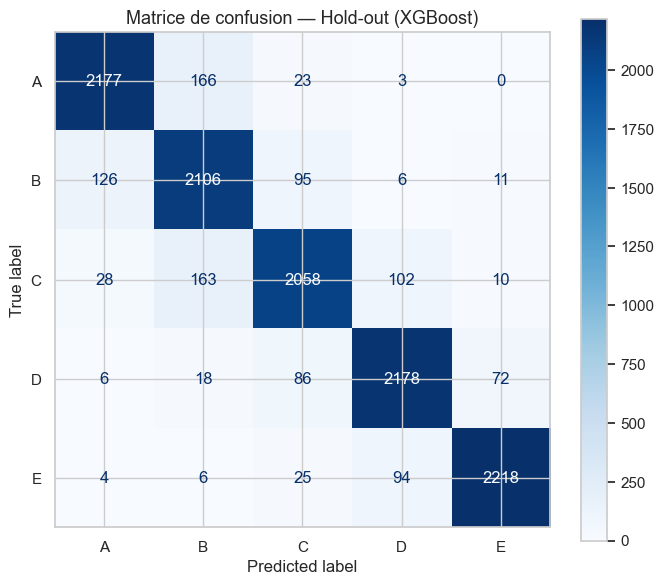

In [12]:
cm = confusion_matrix(y_test_lbl, y_pred, labels=grades)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[g.upper() for g in grades])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matrice de confusion — Hold-out (XGBoost)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Analyse SHAP — Interpretabilite du modele

SHAP (SHapley Additive exPlanations) permet de comprendre l'impact de chaque feature sur les predictions du modele.

- **SHAP summary plot** : vue globale de l'importance et de la direction des features  
- **SHAP bar plot** : importance moyenne (|SHAP|) par feature  
- **SHAP dependence plot** : relation entre une feature et ses valeurs SHAP  
- **SHAP force plot** : explication d'une prediction individuelle  
- **SHAP par classe** : importance des features pour chaque grade Nutri-Score

In [13]:
if not SHAP_OK:
    print("SHAP n'est pas installe. Installez-le avec : pip install shap")
else:
    # On extrait l'imputer et le classifieur du meilleur pipeline
    best_imputer = best_pipeline.named_steps['imputer']
    best_clf     = best_pipeline.named_steps['clf']

    # Appliquer l'imputation sur les donnees de test
    X_test_imputed = best_imputer.transform(X_test)
    X_test_imputed = pd.DataFrame(X_test_imputed, columns=features_dispo)

    print(f"Donnees de test apres imputation : {X_test_imputed.shape}")
    print("Calcul des valeurs SHAP en cours...")

Donnees de test apres imputation : (11781, 10)
Calcul des valeurs SHAP en cours...


In [14]:
if SHAP_OK:
    # Creer l'explainer SHAP pour XGBoost (TreeExplainer est le plus rapide)
    if XGB_OK:
        explainer = shap.TreeExplainer(best_clf)
    else:
        # Pour GradientBoostingClassifier, on utilise un echantillon pour la vitesse
        sample_idx = np.random.choice(len(X_test_imputed), size=500, replace=False)
        X_sample   = X_test_imputed.iloc[sample_idx]
        explainer  = shap.Explainer(best_clf.predict_proba, X_sample)

    # Calculer les valeurs SHAP
    # Pour XGBoost multiclasse, shap_values est une list de 5 matrices (une par classe)
    shap_values = explainer(X_test_imputed)
    print(f"Type shap_values : {type(shap_values)}")
    if hasattr(shap_values, 'values'):
        print(f"Shape shap_values.values : {shap_values.values.shape}")
    print("Valeurs SHAP calculees avec succes !")

Type shap_values : <class 'shap._explanation.Explanation'>
Shape shap_values.values : (11781, 10, 5)
Valeurs SHAP calculees avec succes !


### 7.1 SHAP Summary Plot — Vue globale (toutes classes)

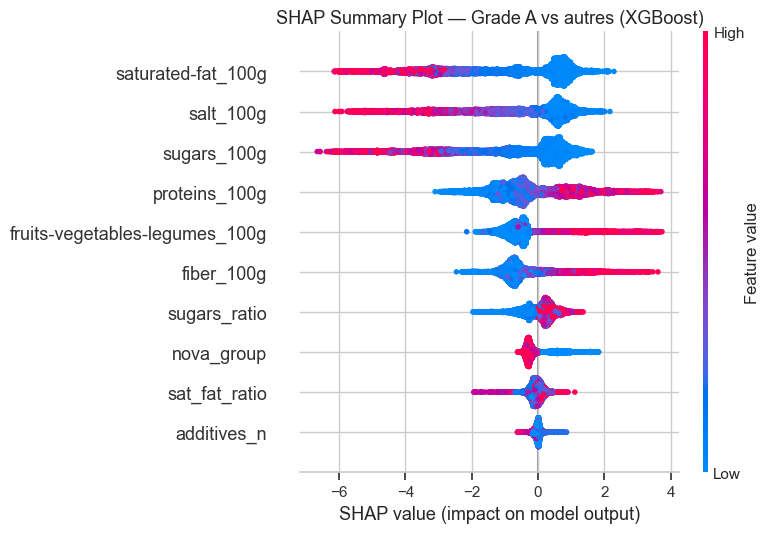

In [15]:
if SHAP_OK:
    # Pour le multiclasse, on utilise la valeur SHAP moyenne sur toutes les classes
    # shap_values.values a la shape (n_samples, n_features, n_classes) pour XGBoost
    if len(shap_values.values.shape) == 3:
        shap_vals_mean = np.abs(shap_values.values).mean(axis=2)  # moyenne sur les classes
        shap_vals_for_plot = shap_values.values[:, :, 0]  # grade A pour le summary plot
    else:
        shap_vals_mean = shap_values.values
        shap_vals_for_plot = shap_values.values

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(
        shap_vals_for_plot,
        X_test_imputed,
        feature_names=features_dispo,
        plot_type='dot',
        show=False
    )
    plt.title('SHAP Summary Plot — Grade A vs autres (XGBoost)', fontsize=13)
    plt.tight_layout()
    plt.show()

### 7.2 SHAP Bar Plot — Importance globale des features

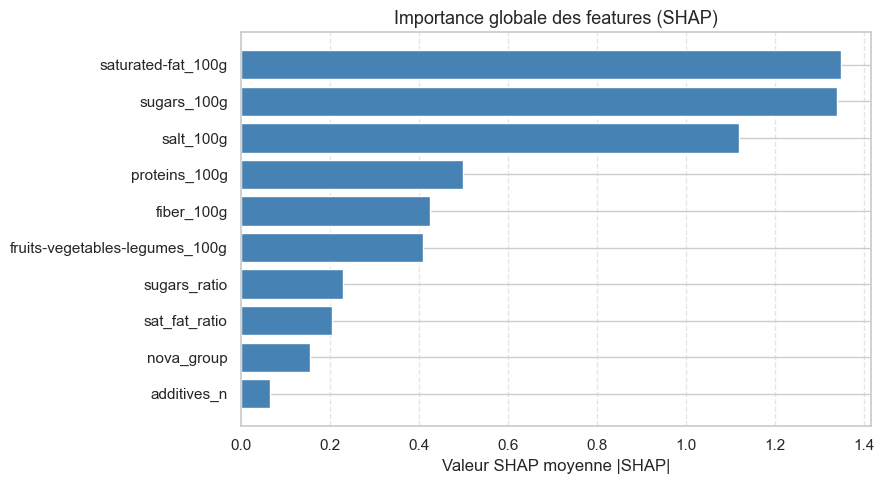


Top features par importance SHAP (toutes classes) :
                       Feature  SHAP moyen
            saturated-fat_100g    1.347210
                   sugars_100g    1.339679
                     salt_100g    1.119390
                 proteins_100g    0.498950
                    fiber_100g    0.424728
fruits-vegetables-legumes_100g    0.408407
                  sugars_ratio    0.229250
                 sat_fat_ratio    0.204754
                    nova_group    0.155236
                   additives_n    0.065638


In [16]:
if SHAP_OK:
    # Importance moyenne |SHAP| sur toutes les classes
    if len(shap_values.values.shape) == 3:
        mean_shap = np.abs(shap_values.values).mean(axis=(0, 2))
    else:
        mean_shap = np.abs(shap_values.values).mean(axis=0)

    df_shap_importance = pd.DataFrame({
        'Feature'   : features_dispo,
        'SHAP moyen': mean_shap
    }).sort_values('SHAP moyen', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(df_shap_importance['Feature'], df_shap_importance['SHAP moyen'],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Valeur SHAP moyenne |SHAP|')
    ax.set_title('Importance globale des features (SHAP)', fontsize=13)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print("\nTop features par importance SHAP (toutes classes) :")
    print(df_shap_importance.sort_values('SHAP moyen', ascending=False).to_string(index=False))

### 7.3 SHAP par classe — Importance des features pour chaque grade

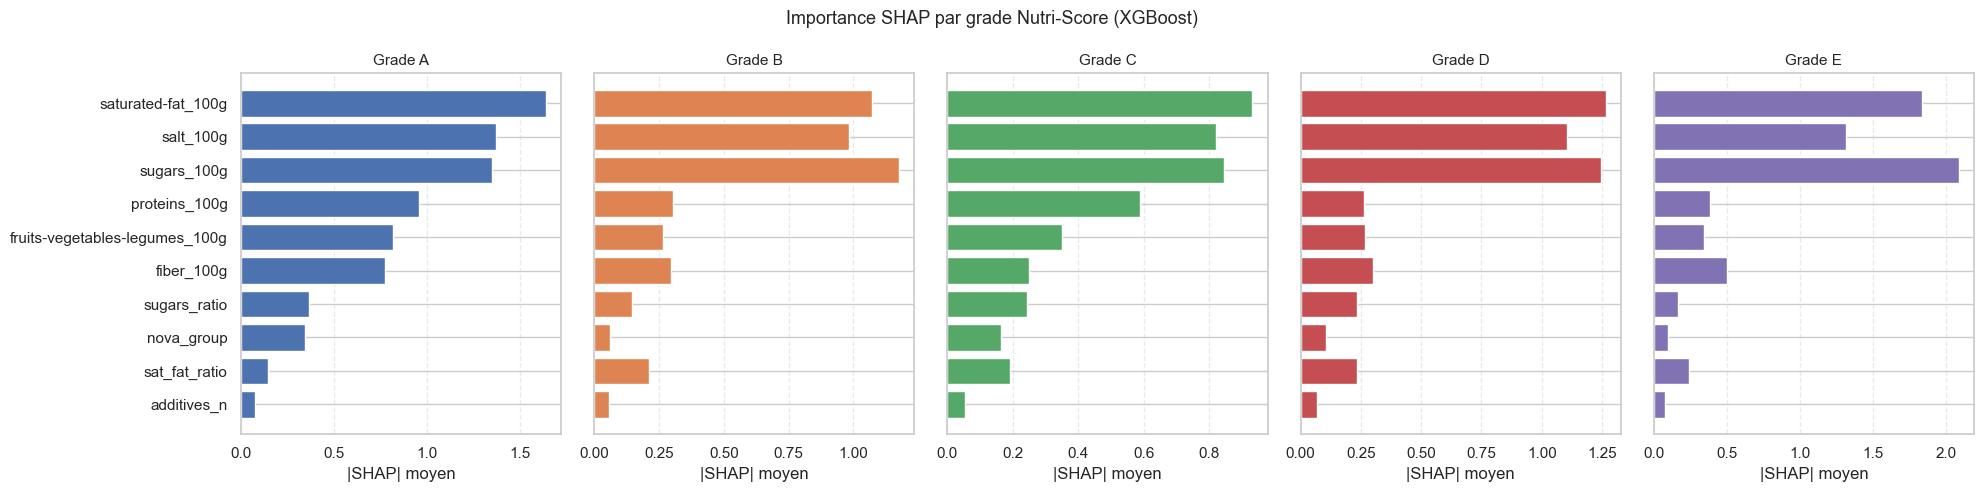

In [17]:
if SHAP_OK and len(shap_values.values.shape) == 3:
    n_classes = shap_values.values.shape[2]
    class_names = le.classes_  # ['a', 'b', 'c', 'd', 'e']

    fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 5), sharey=True)

    for i, (ax, cls) in enumerate(zip(axes, class_names)):
        shap_cls = shap_values.values[:, :, i]
        mean_abs = np.abs(shap_cls).mean(axis=0)
        idx_sort = np.argsort(mean_abs)

        ax.barh(
            [features_dispo[j] for j in idx_sort],
            mean_abs[idx_sort],
            color=f'C{i}',
            edgecolor='white'
        )
        ax.set_title(f'Grade {cls.upper()}', fontsize=11)
        ax.set_xlabel('|SHAP| moyen')
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    fig.suptitle('Importance SHAP par grade Nutri-Score (XGBoost)', fontsize=13)
    plt.tight_layout()
    plt.show()

### 7.4 SHAP Dependence Plot — Relation feature / valeur SHAP

Feature la plus importante : saturated-fat_100g


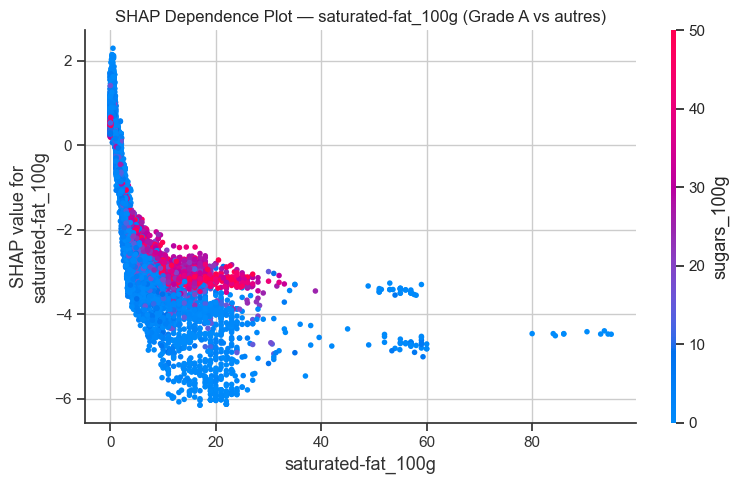

In [18]:
if SHAP_OK:
    # On choisit la feature la plus importante (selon SHAP moyen)
    if len(shap_values.values.shape) == 3:
        mean_shap_all = np.abs(shap_values.values).mean(axis=(0, 2))
        top_feature_idx = int(np.argmax(mean_shap_all))
        shap_to_plot = shap_values.values[:, :, 0]  # classe 0 = grade A
    else:
        mean_shap_all = np.abs(shap_values.values).mean(axis=0)
        top_feature_idx = int(np.argmax(mean_shap_all))
        shap_to_plot = shap_values.values

    top_feature_name = features_dispo[top_feature_idx]
    print(f"Feature la plus importante : {top_feature_name}")

    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(
        top_feature_idx,
        shap_to_plot,
        X_test_imputed.values,
        feature_names=features_dispo,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence Plot — {top_feature_name} (Grade A vs autres)', fontsize=12)
    plt.tight_layout()
    plt.show()

### 7.5 SHAP Force Plot — Explication d'une prediction individuelle

Echantillon #0
  Prediction : Grade C
  Verite     : Grade C

Valeurs des features :
  sugars_100g                              12.8000
  saturated-fat_100g                       1.7000
  salt_100g                                0.1200
  fiber_100g                               0.2000
  proteins_100g                            3.2000
  fruits-vegetables-legumes_100g           33.5531
  nova_group                               4.0000
  additives_n                              2.0000
  sugars_ratio                             0.9697
  sat_fat_ratio                            0.6538


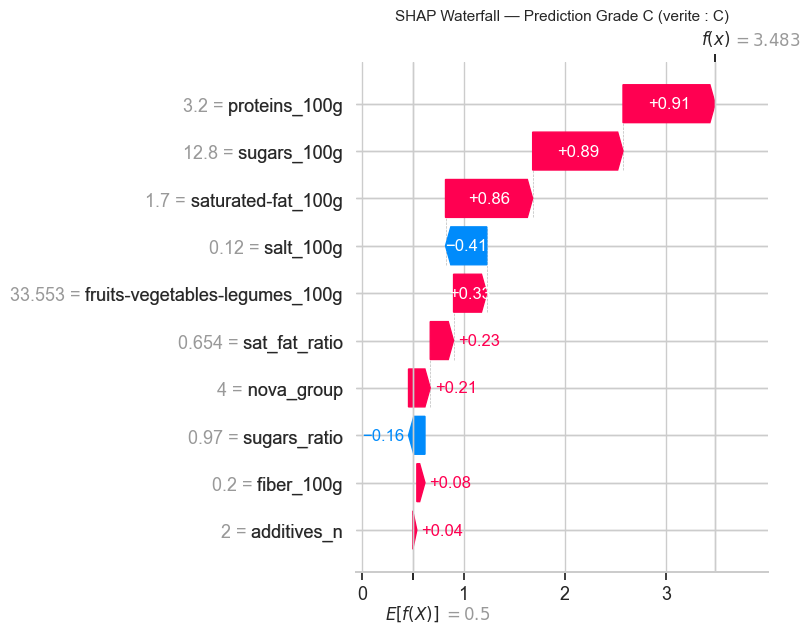

In [19]:
if SHAP_OK and XGB_OK:
    # Choisir un exemple a expliquer (premier echantillon du test set)
    sample_idx = 0
    pred_class_idx = y_pred_enc[sample_idx]
    pred_class_lbl = le.inverse_transform([pred_class_idx])[0]
    true_class_lbl = le.inverse_transform([y_test[sample_idx]])[0]

    print(f"Echantillon #{sample_idx}")
    print(f"  Prediction : Grade {pred_class_lbl.upper()}")
    print(f"  Verite     : Grade {true_class_lbl.upper()}")
    print("\nValeurs des features :")
    for feat, val in zip(features_dispo, X_test_imputed.iloc[sample_idx]):
        print(f"  {feat:<40} {val:.4f}")

    if len(shap_values.values.shape) == 3:
        # SHAP pour la classe predite
        shap_sample = shap_values.values[sample_idx, :, pred_class_idx]
        base_value  = explainer.expected_value[pred_class_idx]
    else:
        shap_sample = shap_values.values[sample_idx]
        base_value  = explainer.expected_value

    # Waterfall plot (equivalent moderne du force plot)
    shap_exp = shap.Explanation(
        values        = shap_sample,
        base_values   = base_value,
        data          = X_test_imputed.iloc[sample_idx].values,
        feature_names = features_dispo
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.plots.waterfall(shap_exp, show=False)
    plt.title(f'SHAP Waterfall — Prediction Grade {pred_class_lbl.upper()} (verite : {true_class_lbl.upper()})',
              fontsize=11)
    plt.tight_layout()
    plt.show()

### 7.6 SHAP Heatmap — Vue d'ensemble des valeurs SHAP sur le jeu de test

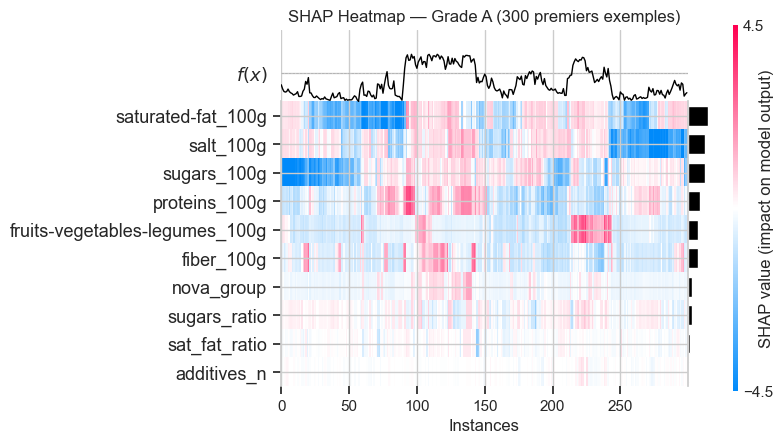

In [20]:
if SHAP_OK and XGB_OK:
    # Heatmap SHAP pour la classe la plus differenciatrice (grade A = classe 0)
    class_to_show = 0  # Grade A

    if len(shap_values.values.shape) == 3:
        shap_cls0 = shap.Explanation(
            values        = shap_values.values[:, :, class_to_show],
            base_values   = np.full(len(X_test_imputed), explainer.expected_value[class_to_show]),
            data          = X_test_imputed.values,
            feature_names = features_dispo
        )
    else:
        shap_cls0 = shap_values

    # Sous-echantillon pour la lisibilite
    n_display = min(300, len(X_test_imputed))
    shap_cls0_sub = shap_cls0[:n_display]

    fig, ax = plt.subplots(figsize=(12, 6))
    shap.plots.heatmap(shap_cls0_sub, show=False)
    plt.title(f'SHAP Heatmap — Grade A ({n_display} premiers exemples)', fontsize=12)
    plt.tight_layout()
    plt.show()

## 8. Predictions sur les donnees sans Nutri-Score

Predictions effectuees : 32,394 produits

Distribution des grades predits :
nutriscore_grade_predit
a    4254
b    5392
c    5919
d    7158
e    9671
Name: count, dtype: int64


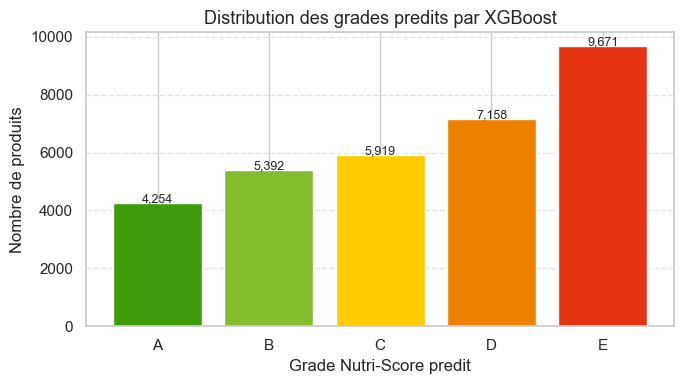

In [21]:
X_pred = df_pred[features_dispo]

y_pred_final_enc = best_pipeline.predict(X_pred)
y_pred_final     = le.inverse_transform(y_pred_final_enc)

df_pred['nutriscore_grade_predit'] = y_pred_final

print(f"Predictions effectuees : {len(df_pred):,} produits")
print("\nDistribution des grades predits :")
print(df_pred['nutriscore_grade_predit'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
dist = df_pred['nutriscore_grade_predit'].value_counts().sort_index()
colors = ['#3F9B0B', '#85BB2F', '#FFCC01', '#EE8100', '#E63312']
ax.bar(dist.index.str.upper(), dist.values, color=colors, edgecolor='white')
for i, (idx, val) in enumerate(dist.items()):
    ax.text(i, val + 30, f'{val:,}', ha='center', fontsize=9)
ax.set_xlabel('Grade Nutri-Score predit')
ax.set_ylabel('Nombre de produits')
ax.set_title('Distribution des grades predits par XGBoost', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. SHAP sur les predictions (analyse des produits sans grade)

SHAP calcule sur 1000 produits a predire.


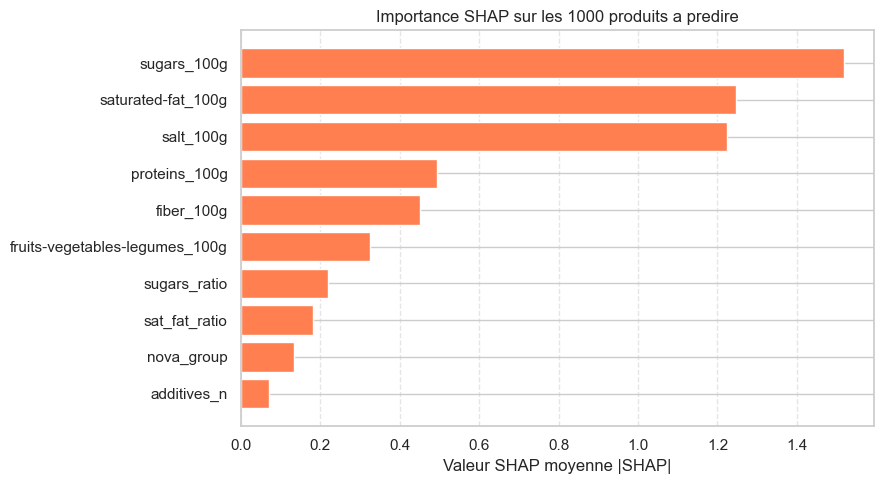

In [22]:
if SHAP_OK and XGB_OK:
    best_imputer_pred = best_pipeline.named_steps['imputer']
    X_pred_imputed    = best_imputer_pred.transform(X_pred)
    X_pred_imputed_df = pd.DataFrame(X_pred_imputed, columns=features_dispo)

    # Sous-echantillon de 1000 produits pour la rapidite
    n_sample = min(1000, len(X_pred_imputed_df))
    idx_sample = np.random.RandomState(42).choice(len(X_pred_imputed_df), n_sample, replace=False)
    X_pred_sample = X_pred_imputed_df.iloc[idx_sample]

    shap_pred_values = explainer(X_pred_sample)

    print(f"SHAP calcule sur {n_sample} produits a predire.")

    # Bar plot de l'importance des features pour les produits a predire
    if len(shap_pred_values.values.shape) == 3:
        mean_shap_pred = np.abs(shap_pred_values.values).mean(axis=(0, 2))
    else:
        mean_shap_pred = np.abs(shap_pred_values.values).mean(axis=0)

    df_shap_pred = pd.DataFrame({
        'Feature'   : features_dispo,
        'SHAP moyen': mean_shap_pred
    }).sort_values('SHAP moyen', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(df_shap_pred['Feature'], df_shap_pred['SHAP moyen'],
            color='coral', edgecolor='white')
    ax.set_xlabel('Valeur SHAP moyenne |SHAP|')
    ax.set_title(f'Importance SHAP sur les {n_sample} produits a predire', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## 10. Export des predictions

In [23]:
import os

output_path = 'predictions_xgboost.csv'
df_pred[['nutriscore_grade_predit']].to_csv(output_path, index=False)
print(f"Predictions exportees dans : {os.path.abspath(output_path)}")
print(f"Nombre de produits : {len(df_pred):,}")

Predictions exportees dans : c:\Users\Gambey\Documents\GitHub\Open-Food-Fact-label\Nutri\predictions_xgboost.csv
Nombre de produits : 32,394


---
## Recapitulatif

| Etape | Description |
|-------|-------------|
| **Feature Engineering** | 7 nutriments de base + NOVA, additifs, ratios |
| **Imputation** | IterativeImputer avec ExtraTreesRegressor |
| **Modele** | XGBoost (XGBClassifier, multiclasse) |
| **Optimisation** | RandomizedSearchCV (15 iterations, CV=3) |
| **Evaluation** | Hold-out 20%, Accuracy + F1-macro |
| **Interpretabilite** | SHAP (TreeExplainer) : summary, bar, dependence, waterfall, heatmap |